# Lab 1 - Glass Identification Dataset - EDA + PCA

In [113]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

## Load the dataset

In [114]:
glass_repo = fetch_ucirepo(id=42)

X_g = glass_repo.data.features
y_g = glass_repo.data.targets

df_g = X_g.copy()
df_g['type'] = y_g.iloc[:, 0].values

# Meaningful labels for glass types
glass_type_labels = {
    1: 'Build. wind. (float)',
    2: 'Build. wind. (non-float)',
    3: 'Vehicle wind.',
    4: 'Containers',
    5: 'Tableware',
    6: 'Headlamps'
}
df_g['type_label'] = df_g['type'].map(glass_type_labels)

# Main vs secondary component grouping used throughout EDA
main_components = ['RI', 'Na', 'Si', 'Ca']
main_oxides = ['Na', 'Si', 'Ca']
secondary_components = [c for c in X_g.columns if c not in main_components]

# Projector-friendly, high-contrast palette (colorblind-safe style)
glass_palette = {
    'Build. wind. (float)':     '#0072B2',  # blue
    'Build. wind. (non-float)': '#E69F00',  # orange
    'Vehicle wind.':            '#009E73',  # green
    'Containers':               '#CC79A7',  # magenta
    'Tableware':                '#D55E00',  # vermillion
    'Headlamps':                '#56B4E9',  # sky blue
}


## EDA

### 1. Dataset Overview

In [115]:
print(f"Number of instances (rows): {X_g.shape[0]}")
print(f"Number of attributes (columns): {X_g.shape[1]}")
print(f"\nFeature names: {list(X_g.columns)}")
print(f"\nData types:\n{X_g.dtypes}")

# First and last rows – sanity check on loading & ordering
print("\nFirst 5 rows:")
display(X_g.head())
print("\nLast 5 rows:")
display(X_g.tail())

print("\nDescriptive statistics of attributes:")
display(X_g.describe())

print("\nClass distribution in the dataset:")
print(df_g['type_label'].value_counts())


Number of instances (rows): 214
Number of attributes (columns): 9

Feature names: ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe']

Data types:
RI    float64
Na    float64
Mg    float64
Al    float64
Si    float64
K     float64
Ca    float64
Ba    float64
Fe    float64
dtype: object

First 5 rows:


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0



Last 5 rows:


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
209,1.51623,14.14,0.0,2.88,72.61,0.08,9.18,1.06,0.0
210,1.51685,14.92,0.0,1.99,73.06,0.00,8.40,1.59,0.0
211,1.52065,14.36,0.0,2.02,73.42,0.00,8.44,1.64,0.0
212,1.51651,14.38,0.0,1.94,73.61,0.00,8.48,1.57,0.0
213,1.51711,14.23,0.0,2.08,73.36,0.00,8.62,1.67,0.0



Descriptive statistics of attributes:


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000



Class distribution in the dataset:
type_label
Build. wind. (non-float)    76
Build. wind. (float)        70
Vehicle wind.               17
Tableware                   13
Headlamps                    9
Name: count, dtype: int64


### 2. Data Quality Checks

In [116]:
print("Missing values per feature:")
display(X_g.isnull().sum().rename("Missing Count").to_frame())
print(f"\nTotal missing values: {X_g.isnull().sum().sum()}")

# Duplicates
n_dupes_g = df_g.duplicated().sum()
print(f"\nDuplicate rows: {n_dupes_g}")
if n_dupes_g > 0:
    print("Duplicated entries:")
    display(df_g[df_g.duplicated(keep=False)].sort_values(list(X_g.columns)))

# Zeros in MAIN components (for this dataset these are suspicious)
main_without_ri = [c for c in main_components if c != 'RI']
print(f"\nZero counts in main components {main_components} (zeros are domain-suspicious):")
display((X_g[main_components] == 0).sum().rename("Zero Count").to_frame())

# Zeros in SECONDARY components
print(f"\nZero counts in secondary components {secondary_components}:")
display((X_g[secondary_components] == 0).sum().rename("Zero Count").to_frame())

# Negative values – oxide percentages and RI should be non-negative
print("\nNegative value counts per feature:")
display((X_g < 0).sum().rename("Negative Count").to_frame())

# Composition sanity check: oxide percentages should sum to ~100%
# (RI is not a percentage, so exclude it)
oxide_cols = [c for c in X_g.columns if c != 'RI']
row_sums = X_g[oxide_cols].sum(axis=1)
print(f"\nOxide percentage row sums – expected ~100%:")
print(row_sums.describe().rename("Row sum").to_frame().T)
outlier_rows = row_sums[(row_sums < 95) | (row_sums > 105)]
if len(outlier_rows):
    print(f"\n{len(outlier_rows)} rows with oxide sums outside [95, 105]% – may indicate data entry errors:")
    display(df_g.loc[outlier_rows.index])

# Common sentinel / placeholder values
for sentinel in [-1, -999, 9999, 999]:
    hits = (X_g == sentinel).sum().sum()
    if hits:
        print(f"\nSentinel value {sentinel} found {hits} time(s)")


Missing values per feature:


,Missing Count
RI,0
Na,0
Mg,0
Al,0
Si,0
K,0
Ca,0
Ba,0
Fe,0



Total missing values: 0

Duplicate rows: 1
Duplicated entries:


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,type,type_label
38,1.52213,14.21,3.82,0.47,71.77,0.11,9.57,0.0,0.0,1,Build. wind. (float)
39,1.52213,14.21,3.82,0.47,71.77,0.11,9.57,0.0,0.0,1,Build. wind. (float)



Zero counts in main components ['RI', 'Na', 'Si', 'Ca'] (zeros are domain-suspicious):


...


Zero counts in secondary components ['Mg', 'Al', 'K', 'Ba', 'Fe']:


,Zero Count
Mg,42
Al,0
K,30
Ba,176
Fe,144



Negative value counts per feature:


,Negative Count
RI,0
Na,0
Mg,0
Al,0
Si,0
K,0
Ca,0
Ba,0
Fe,0



Oxide percentage row sums – expected ~100%:
         count       mean       std    min    25%    50%    75%    max
Row sum  214.0  99.874299  0.122126  99.02  99.81  99.89  99.96  100.1


### 3. Class Balance

Class counts:


,count,percent
type_label,,
Build. wind. (non-float),76,35.5
Build. wind. (float),70,32.7
Vehicle wind.,17,7.9
Tableware,13,6.1
Headlamps,9,4.2


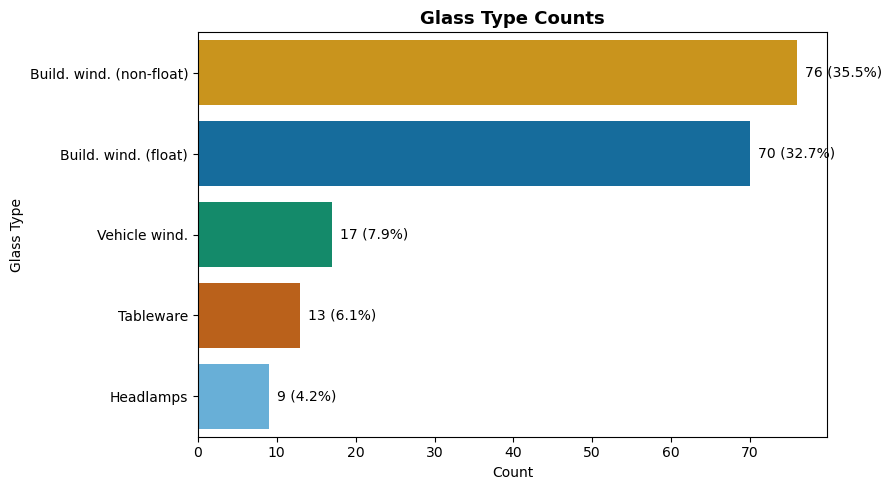

In [117]:
type_counts = df_g['type_label'].value_counts()
type_perc = (type_counts / len(df_g) * 100).round(1)

print('Class counts:')
display(pd.DataFrame({'count': type_counts, 'percent': type_perc}))

plt.figure(figsize=(9, 5))
ax = sns.countplot(data=df_g, y='type_label', order=type_counts.index, hue='type_label', palette=glass_palette, legend=False)
plt.title('Glass Type Counts', fontsize=13, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Glass Type')

for idx, label in enumerate(type_counts.index):
    ax.text(type_counts[label] + 1, idx, f"{type_counts[label]} ({type_perc[label]}%)", va='center')

plt.tight_layout()
plt.show()

### 4. Composition Sanity Check (Oxides Sum to ~100%)

Oxide sum check (excluding RI):
  Exactly 100.0: 5/214
  Within +/- 0.5: 213/214
  Within +/- 1.0: 214/214
  Outside +/- 2.0: 0/214

Summary statistics of oxide sums:


,count,mean,std,min,25%,50%,75%,max
oxide_sum,214.0,99.874299,0.122126,99.02,99.81,99.89,99.96,100.1


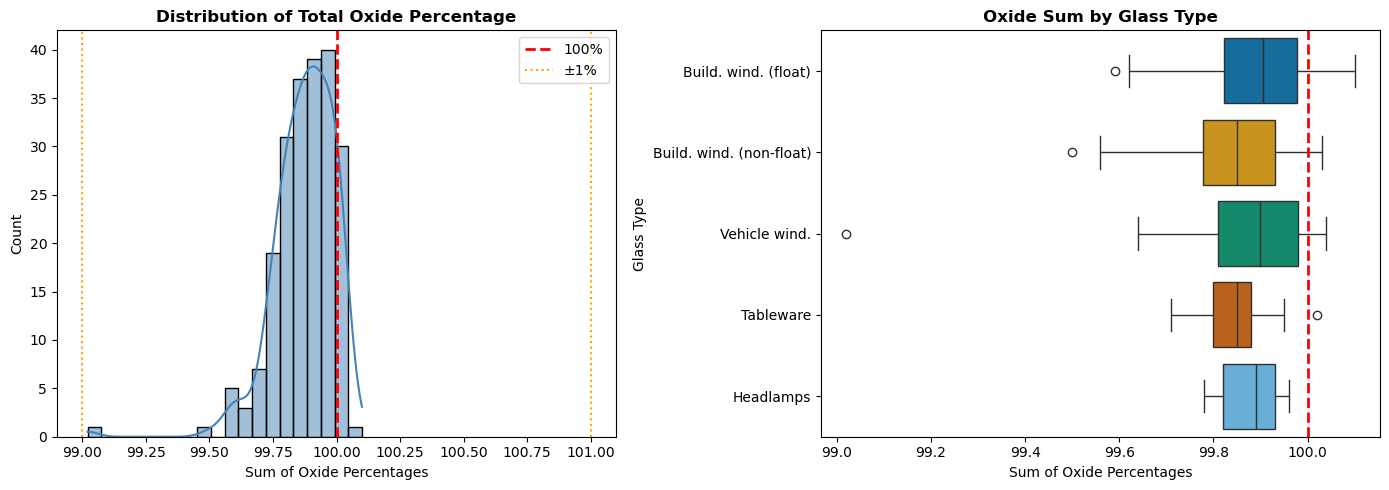

In [118]:
oxide_cols = [col for col in X_g.columns if col != 'RI']
oxide_sum_df = df_g[['type_label']].copy()
oxide_sum_df['oxide_sum'] = X_g[oxide_cols].sum(axis=1)
oxide_sum_df['deviation_from_100'] = oxide_sum_df['oxide_sum'] - 100

exact_100 = np.isclose(oxide_sum_df['oxide_sum'], 100.0, atol=1e-9).sum()
within_05 = np.isclose(oxide_sum_df['oxide_sum'], 100.0, atol=0.5).sum()
within_1 = np.isclose(oxide_sum_df['oxide_sum'], 100.0, atol=1.0).sum()
outside_2 = (~np.isclose(oxide_sum_df['oxide_sum'], 100.0, atol=2.0)).sum()

print('Oxide sum check (excluding RI):')
print(f"  Exactly 100.0: {exact_100}/{len(oxide_sum_df)}")
print(f"  Within +/- 0.5: {within_05}/{len(oxide_sum_df)}")
print(f"  Within +/- 1.0: {within_1}/{len(oxide_sum_df)}")
print(f"  Outside +/- 2.0: {outside_2}/{len(oxide_sum_df)}")
print('\nSummary statistics of oxide sums:')
display(oxide_sum_df['oxide_sum'].describe().to_frame().T)

far_rows = oxide_sum_df.loc[~np.isclose(oxide_sum_df['oxide_sum'], 100.0, atol=2.0)]
if len(far_rows) > 0:
    print('\nRows with oxide sums farther than +/- 2.0 from 100:')
    display(df_g.loc[far_rows.index, oxide_cols + ['type_label']].assign(oxide_sum=oxide_sum_df.loc[far_rows.index, 'oxide_sum']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(oxide_sum_df['oxide_sum'], bins=20, kde=True, color='steelblue', ax=axes[0])
axes[0].axvline(100, color='red', linestyle='--', linewidth=2, label='100%')
axes[0].axvline(99, color='orange', linestyle=':', linewidth=1.5, label='±1%')
axes[0].axvline(101, color='orange', linestyle=':', linewidth=1.5)
axes[0].set_title('Distribution of Total Oxide Percentage', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sum of Oxide Percentages')
axes[0].legend()

sns.boxplot(data=oxide_sum_df, x='oxide_sum', y='type_label', hue='type_label', palette=glass_palette, legend=False, ax=axes[1])
axes[1].axvline(100, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Oxide Sum by Glass Type', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sum of Oxide Percentages')
axes[1].set_ylabel('Glass Type')

plt.tight_layout()
plt.show()

### 5. Correlation Heatmap (All Features)

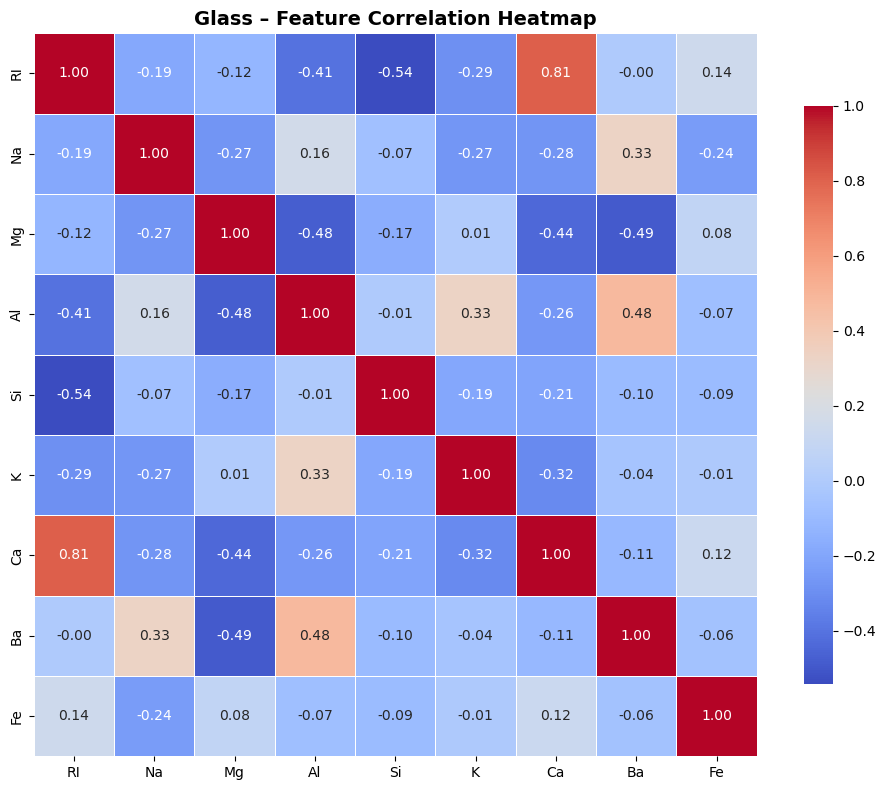

In [119]:
plt.figure(figsize=(10, 8))
corr_g = X_g.corr()
sns.heatmap(
    corr_g,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Glass – Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 6. Attribute Relationships with RI (lmplot)

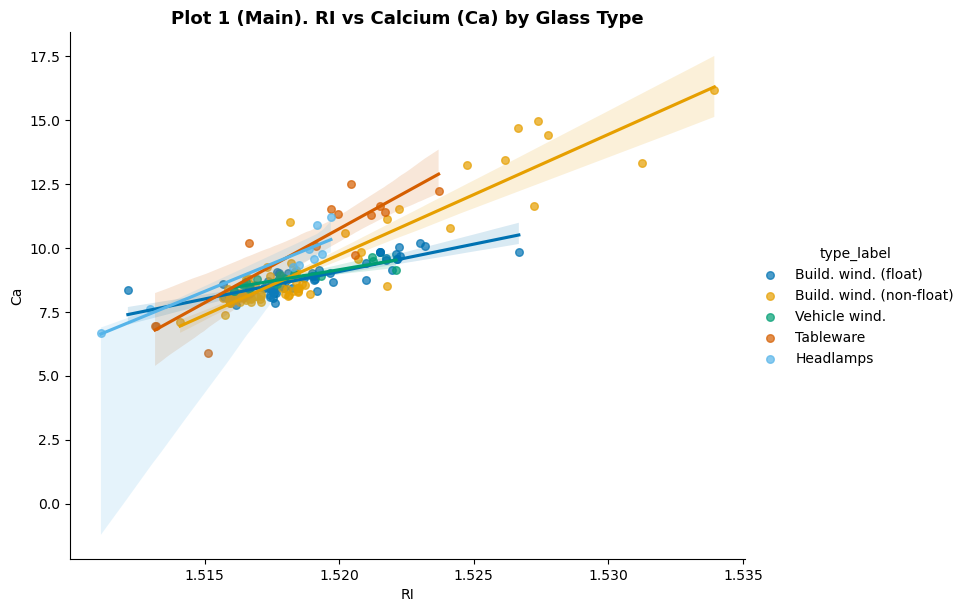

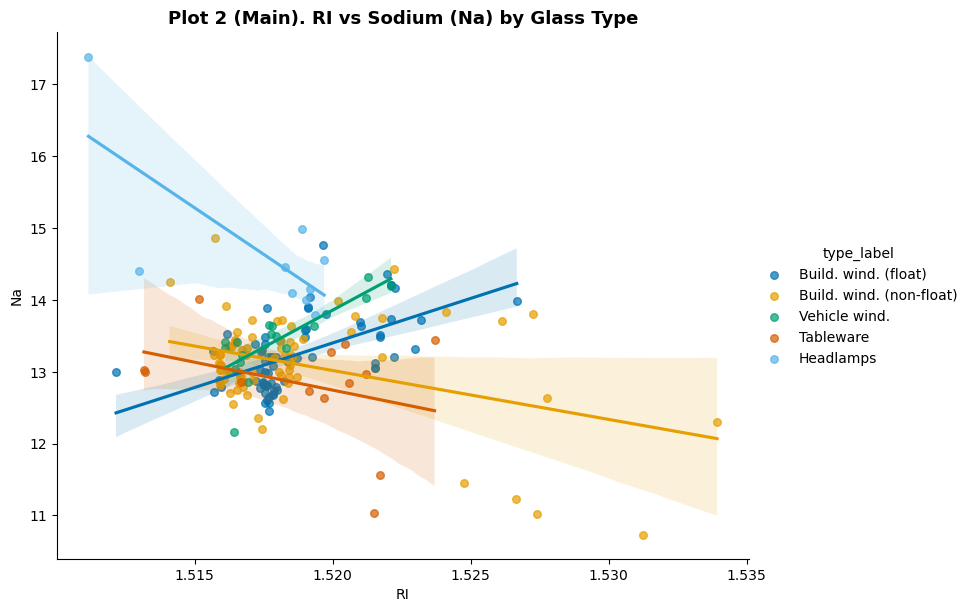

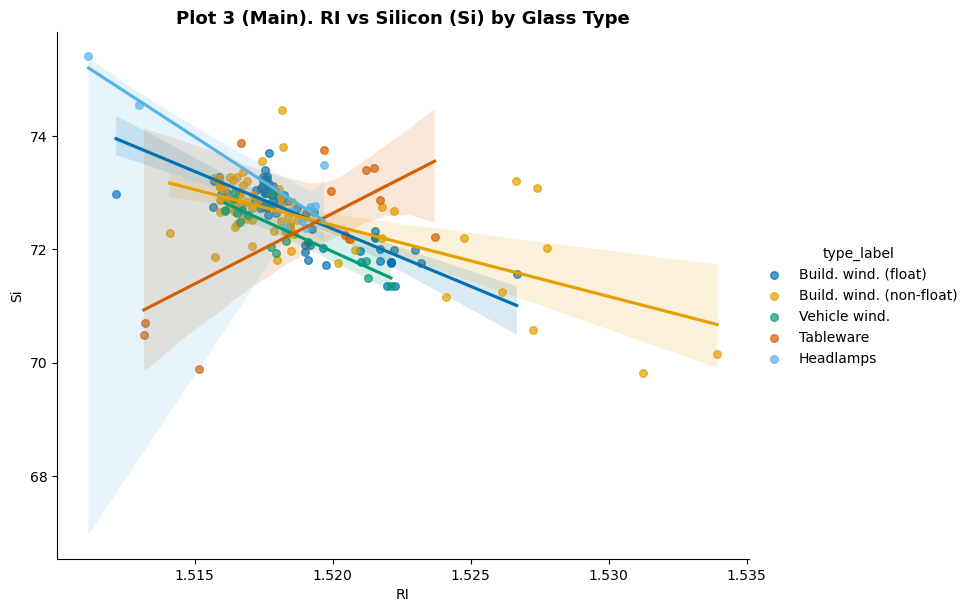

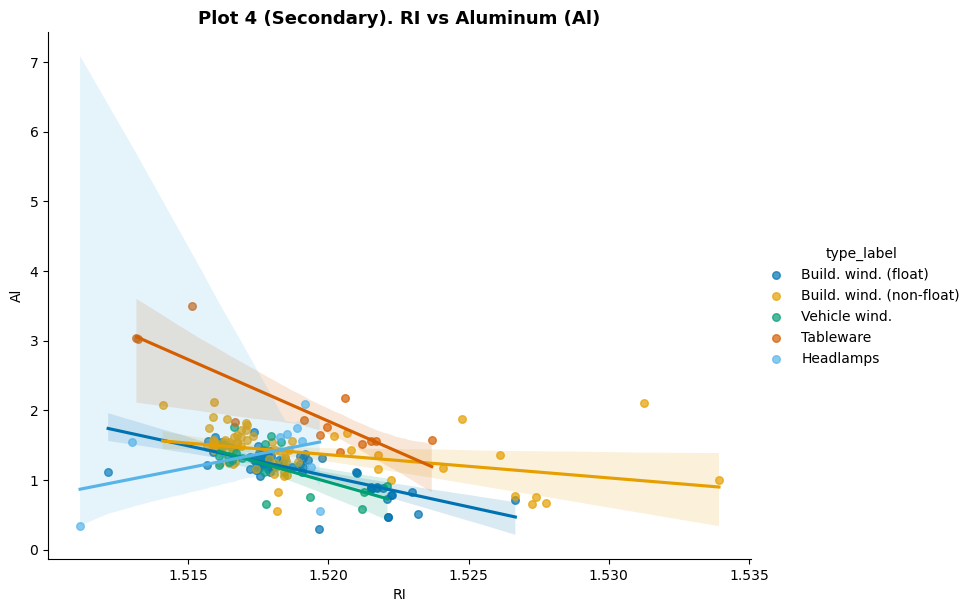

In [120]:
# Main component view: RI vs Ca, Na, Si by glass type
for y_col, title in [
    ('Ca', 'Plot 1 (Main). RI vs Calcium (Ca)'),
    ('Na', 'Plot 2 (Main). RI vs Sodium (Na)'),
    ('Si', 'Plot 3 (Main). RI vs Silicon (Si)')
]:
    sns.lmplot(
        data=df_g,
        x='RI',
        y=y_col,
        hue='type_label',
        palette=glass_palette,
        fit_reg=True,
        height=6,
        aspect=1.3,
        scatter_kws={'s': 30, 'alpha': 0.7}
    )
    plt.title(f'{title} by Glass Type', fontsize=13, fontweight='bold')
    plt.show()

# Secondary example: RI vs Al (one representative secondary component)
sns.lmplot(
    data=df_g,
    x='RI',
    y='Al',
    hue='type_label',
    palette=glass_palette,
    fit_reg=True,
    height=6,
    aspect=1.3,
    scatter_kws={'s': 30, 'alpha': 0.7}
)
plt.title('Plot 4 (Secondary). RI vs Aluminum (Al)', fontsize=13, fontweight='bold')
plt.show()

### 7. Glass Types: Component Comparison by Weight

,Na,Mg,Al,Si,K,Ca,Ba,Fe
type_label,,,,,,,,
Build. wind. (float),13.24,3.55,1.16,72.62,0.45,8.80,0.01,0.06
Build. wind. (non-float),13.11,3.00,1.41,72.60,0.52,9.07,0.05,0.08
Vehicle wind.,13.44,3.54,1.20,72.40,0.41,8.78,0.01,0.06
Tableware,12.83,0.77,2.03,72.37,1.47,10.12,0.19,0.06
Headlamps,14.65,1.31,1.37,73.21,0.00,9.36,0.00,0.00


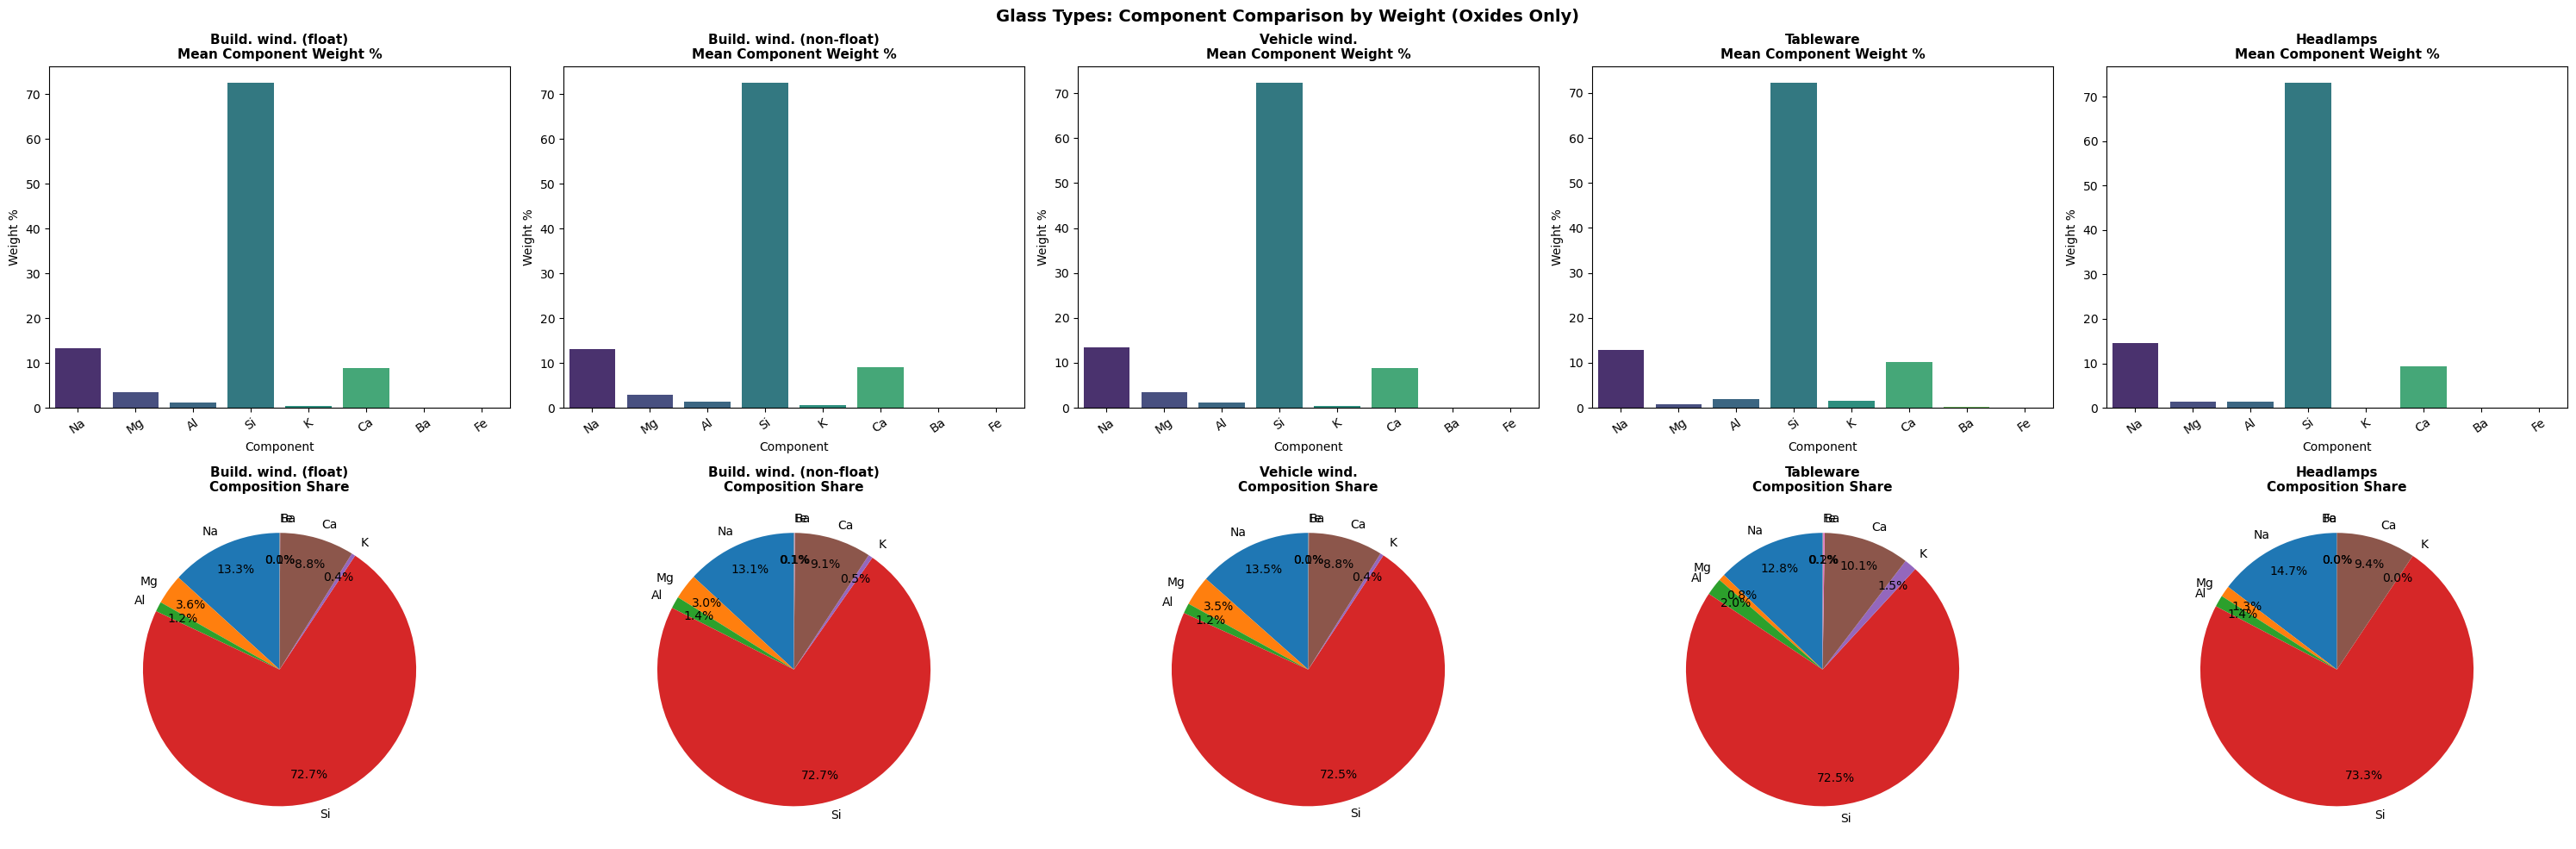

In [121]:
all_types = [
    'Build. wind. (float)',
    'Build. wind. (non-float)',
    'Vehicle wind.',
    'Tableware',
    'Headlamps'
]
oxide_cols = [col for col in X_g.columns if col != 'RI']

type_means = (
    df_g[df_g['type_label'].isin(all_types)]
    .groupby('type_label')[oxide_cols]
    .mean()
    .loc[all_types]
)

display(type_means.style.format('{:.2f}').background_gradient(cmap='YlOrBr', axis=1))

fig, axes = plt.subplots(2, len(all_types), figsize=(6 * len(all_types), 10))

for j, glass_type in enumerate(all_types):
    values = type_means.loc[glass_type]

    # Top row: bar chart by weight percentage
    ax_bar = axes[0, j]
    sns.barplot(x=values.index, y=values.values, hue=values.index, palette='viridis', legend=False, ax=ax_bar)
    ax_bar.set_title(f'{glass_type}\nMean Component Weight %', fontsize=11, fontweight='bold')
    ax_bar.set_xlabel('Component')
    ax_bar.set_ylabel('Weight %')
    ax_bar.tick_params(axis='x', rotation=35)

    # Bottom row: pie chart share of oxide mix
    ax_pie = axes[1, j]
    ax_pie.pie(values.values, labels=values.index, autopct='%1.1f%%', startangle=90, pctdistance=0.8)
    ax_pie.set_title(f'{glass_type}\nComposition Share', fontsize=11, fontweight='bold')

plt.suptitle('Glass Types: Component Comparison by Weight (Oxides Only)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 8. How Main Components Affect RI

In [122]:
type_order = df_g['type_label'].value_counts().index.tolist()

# Pearson correlation of RI with each MAIN oxide (Na, Si, Ca) inside each glass type
ri_corr_by_type = pd.DataFrame(
    {
        glass_type: df_g.loc[df_g['type_label'] == glass_type, ['RI'] + main_oxides]
        .corr()
        .loc[main_oxides, 'RI']
        for glass_type in type_order
    }
).T
ri_corr_by_type.index.name = 'glass_type'
ri_corr_by_type.columns.name = 'oxide'

print('Correlation of RI with MAIN oxides (Na, Si, Ca) inside each glass type:')
display(ri_corr_by_type.style.background_gradient(cmap='coolwarm', axis=None).format('{:.3f}'))

Correlation of RI with MAIN oxides (Na, Si, Ca) inside each glass type:


oxide,Na,Si,Ca
glass_type,,,
Build. wind. (non-float),-0.390,-0.660,0.933
Build. wind. (float),0.563,-0.807,0.846
Vehicle wind.,0.782,-0.821,0.894
Tableware,-0.334,0.650,0.887
Headlamps,-0.744,-0.912,0.929


### 9. Oxide-Only Relationships Within Each Type

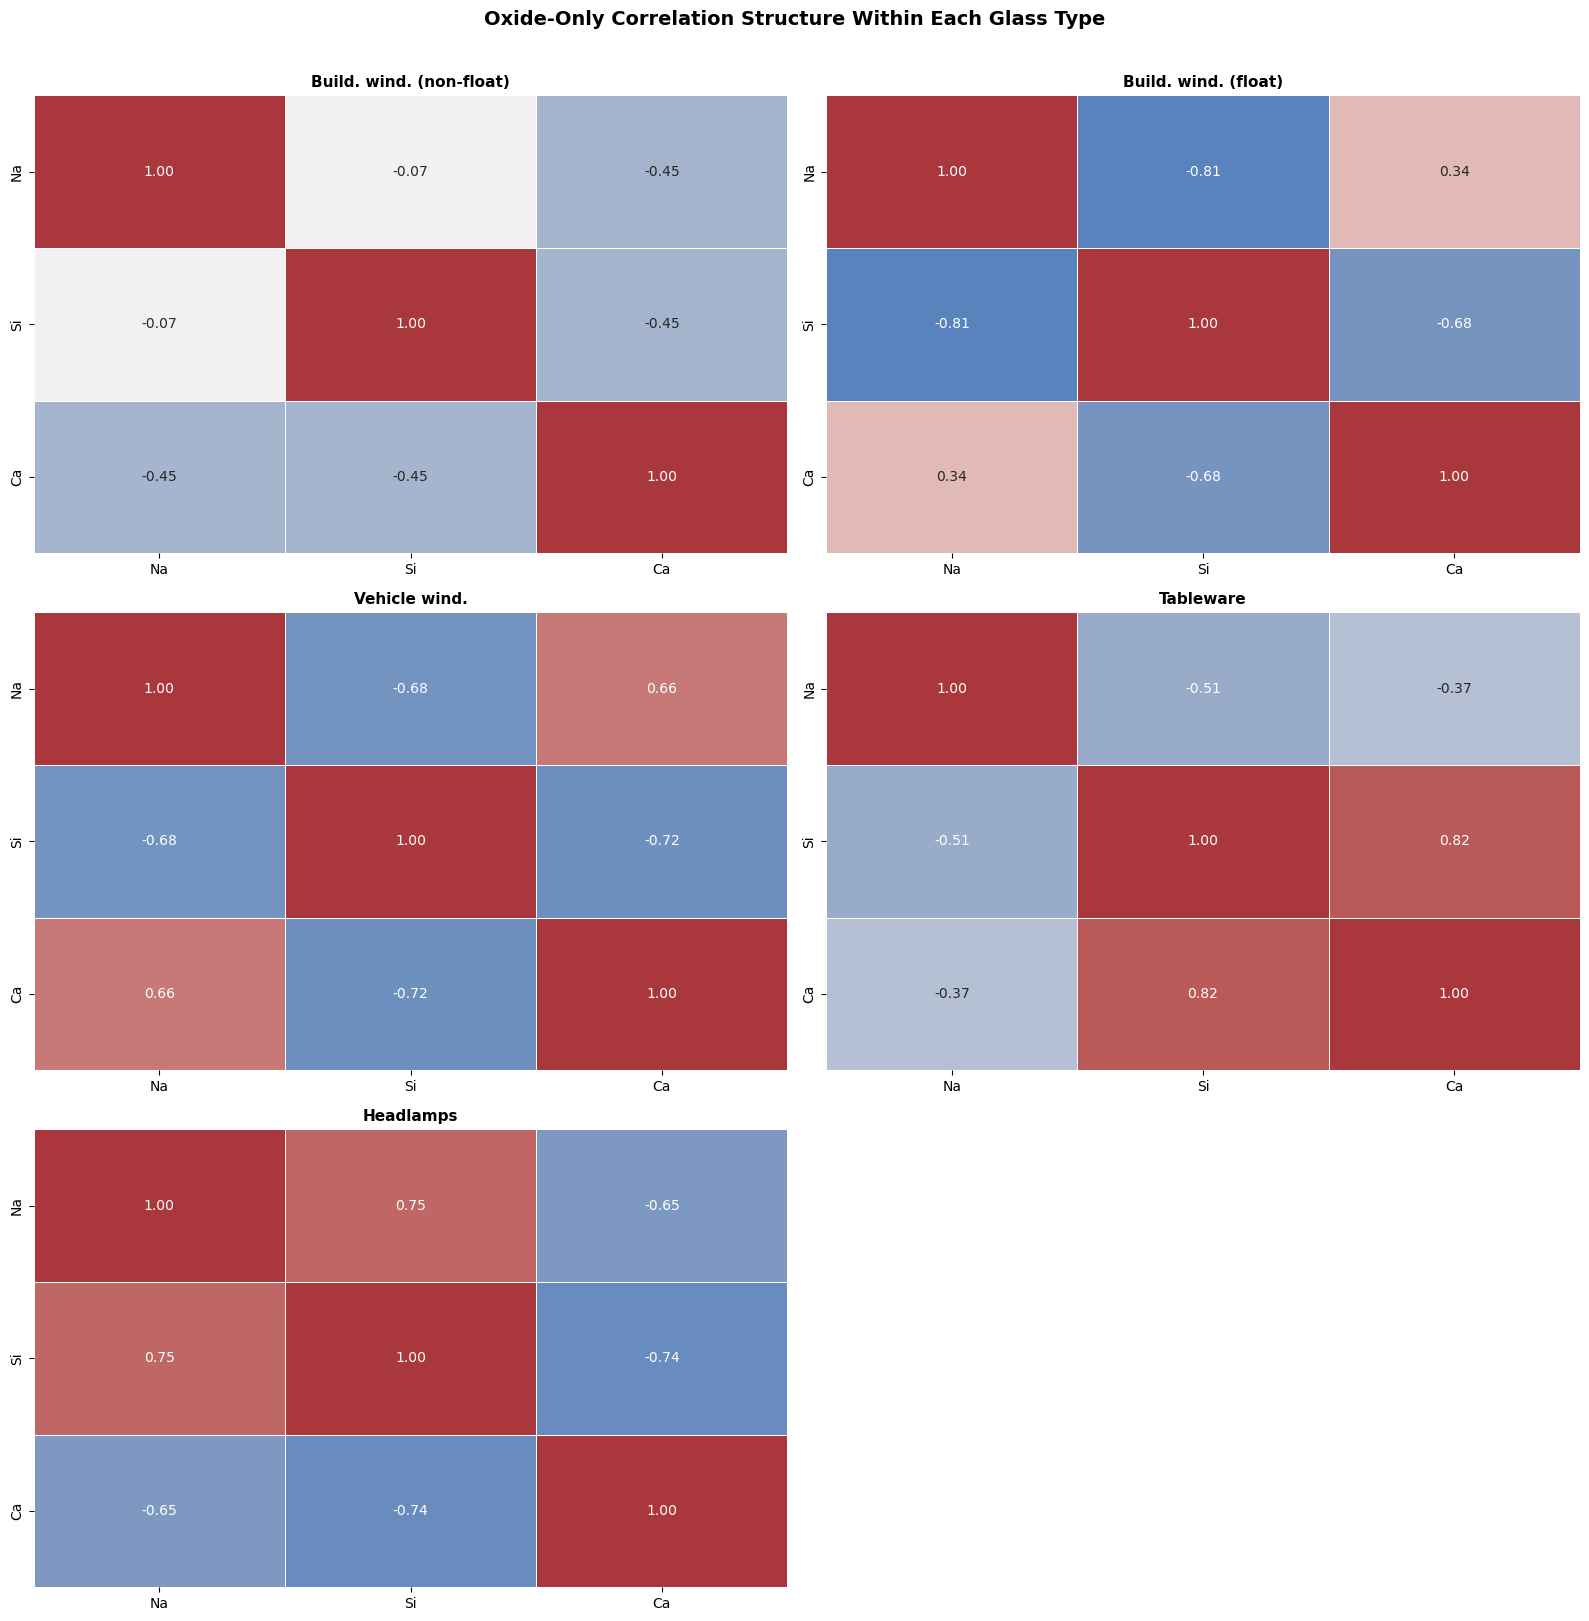

In [123]:
# Oxide-only relationships inside each glass type
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()

type_order = df_g['type_label'].value_counts().index.tolist()
for ax, glass_type in zip(axes, type_order):
    type_corr = df_g.loc[df_g['type_label'] == glass_type, main_oxides].corr()
    sns.heatmap(type_corr, annot=True, fmt='.2f', cmap='vlag', center=0, linewidths=0.4, cbar=False, ax=ax)
    ax.set_title(glass_type, fontsize=11, fontweight='bold')

# Hide any unused subplot slots
for ax in axes[len(type_order):]:
    ax.axis('off')

plt.suptitle('Oxide-Only Correlation Structure Within Each Glass Type', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 10. PairGrid (Main Components)

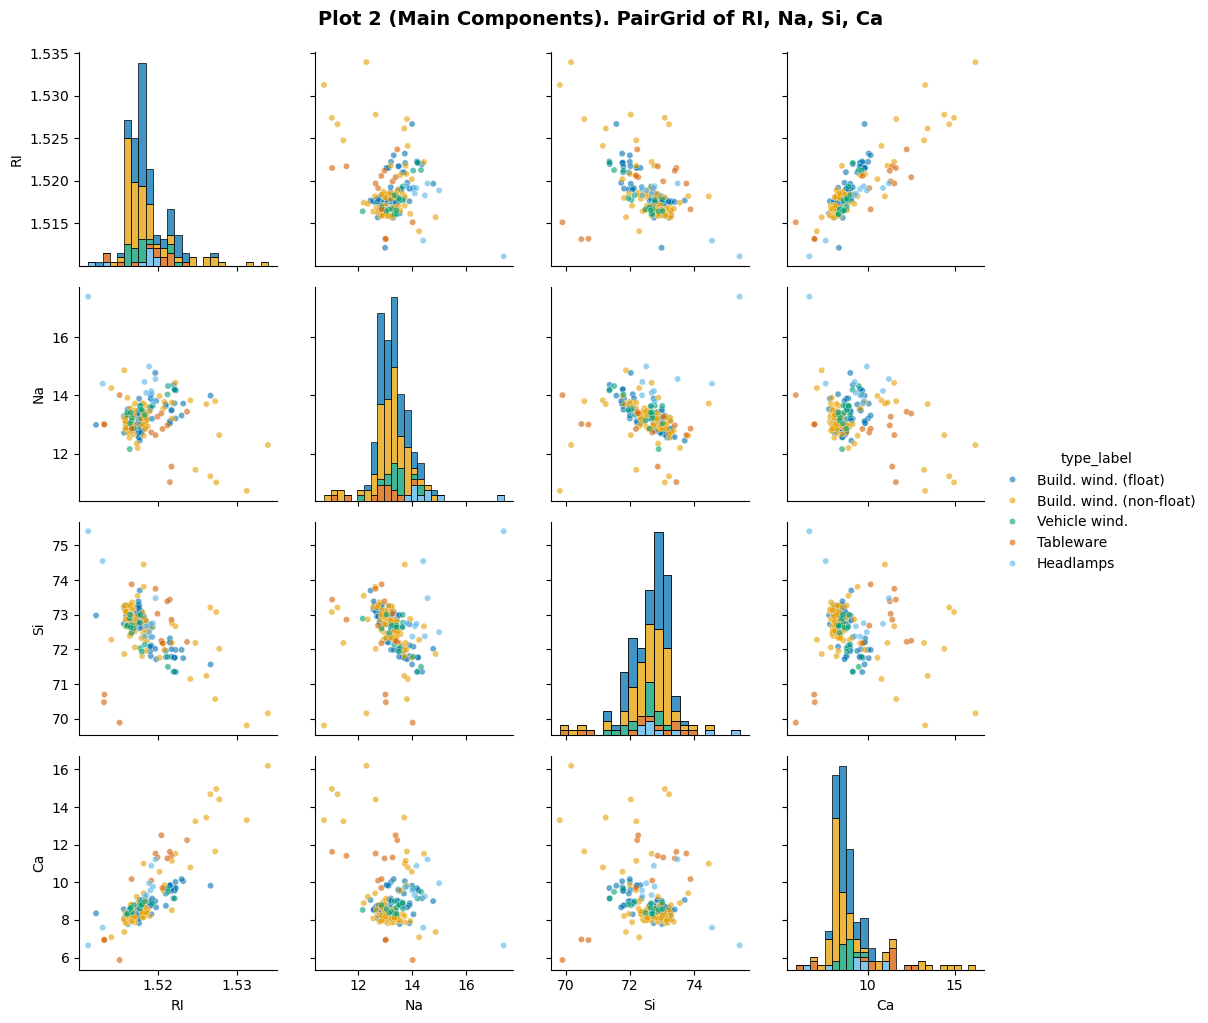

In [124]:
# PairGrid focused on main components (+ type label)
pair_features = ['RI', 'Na', 'Si', 'Ca']
df_g_pair = df_g[pair_features + ['type_label']].copy()

g = sns.PairGrid(df_g_pair, hue='type_label', palette=glass_palette, diag_sharey=False)
g.map_diag(sns.histplot, multiple="stack")
g.map_offdiag(sns.scatterplot, s=20, alpha=0.6)
g.add_legend()
g.fig.suptitle('Plot 2 (Main Components). PairGrid of RI, Na, Si, Ca', y=1.02, fontsize=14, fontweight='bold')
plt.show()


### 11. PairGrid (Non-Main Components)

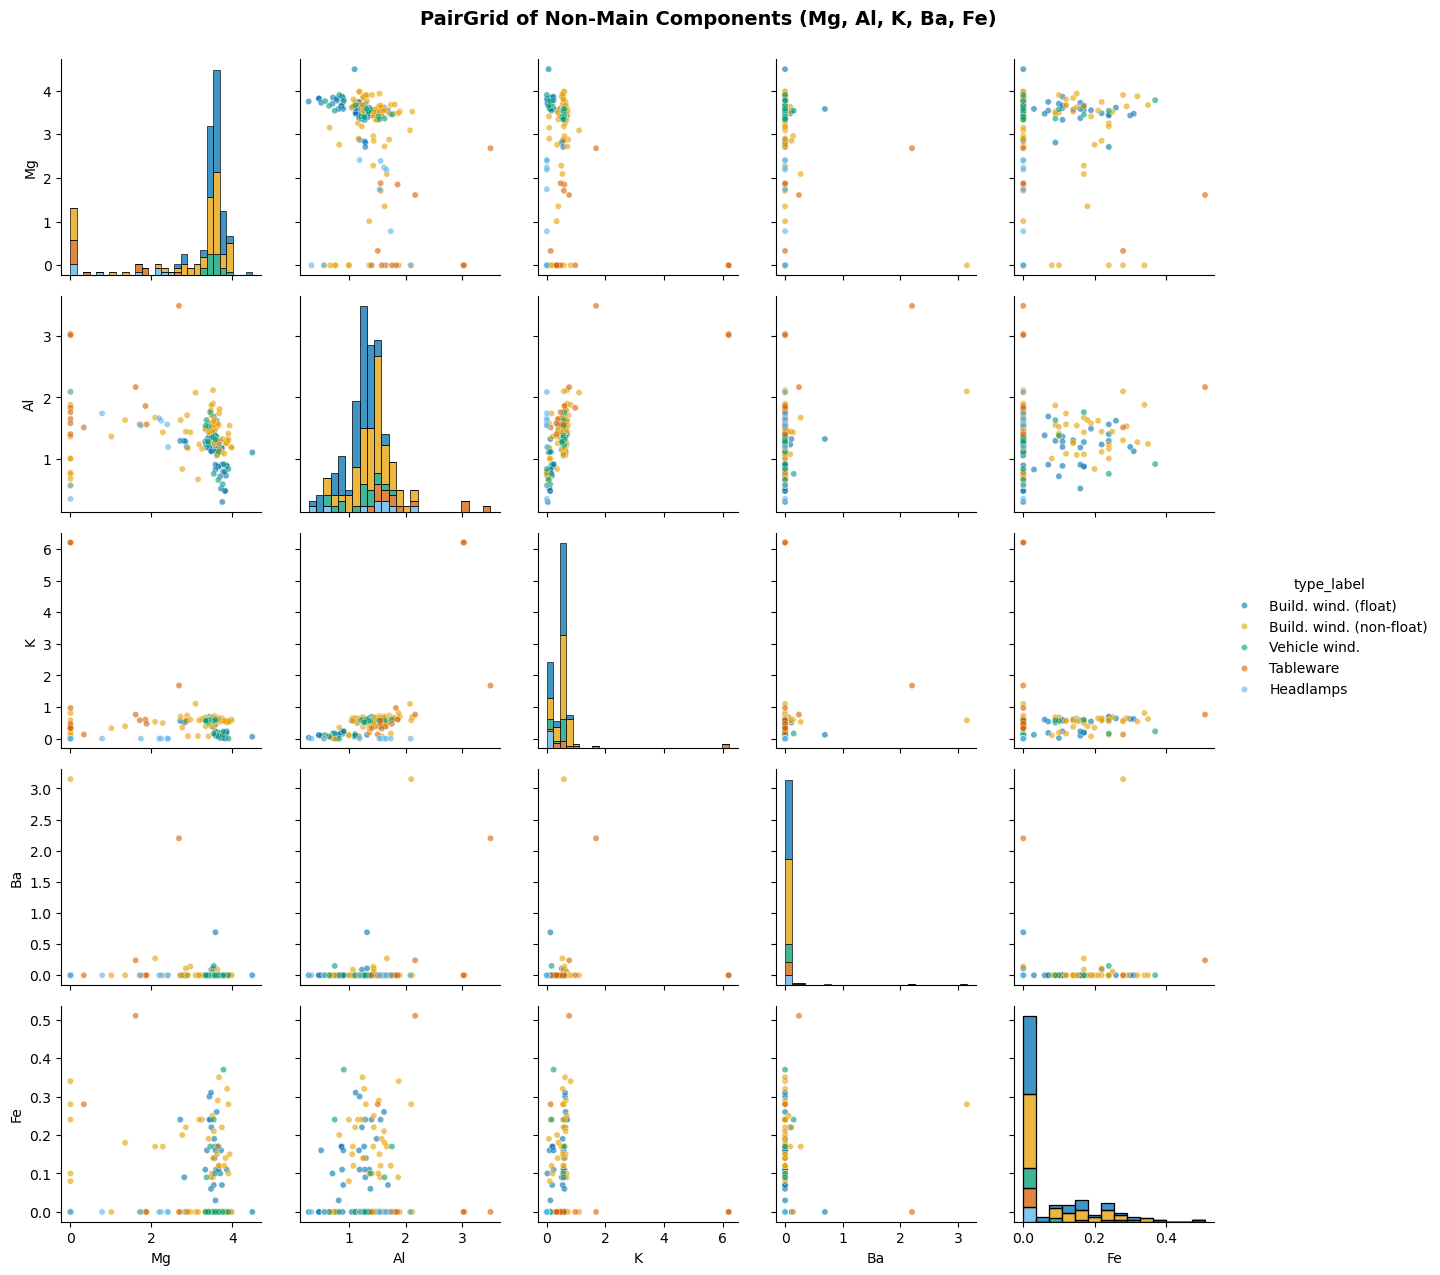

In [125]:
# PairGrid focused on non-main components
non_main_features = [c for c in secondary_components if c in X_g.columns]
df_g_pair_non_main = df_g[non_main_features + ['type_label']].copy()

g_non_main = sns.PairGrid(df_g_pair_non_main, hue='type_label', palette=glass_palette, diag_sharey=False)
g_non_main.map_diag(sns.histplot, multiple='stack')
g_non_main.map_offdiag(sns.scatterplot, s=20, alpha=0.6)
g_non_main.add_legend()
g_non_main.figure.suptitle('PairGrid of Non-Main Components (Mg, Al, K, Ba, Fe)', y=1.02, fontsize=14, fontweight='bold')
plt.show()

### 12. Distribution of Non-Main Components by Glass Type

Using boxplots with jittered points for readability across many components (instead of violin plots).

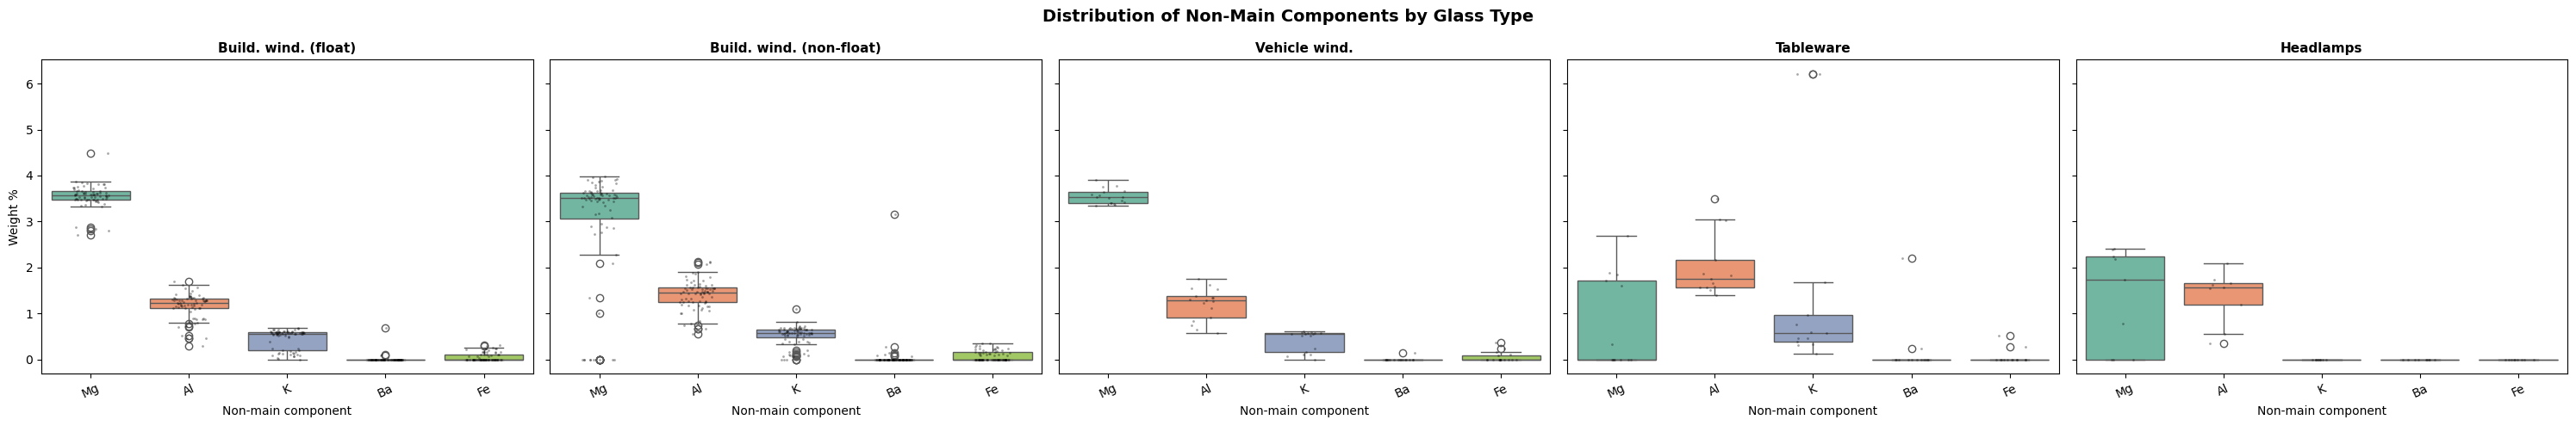

In [126]:
# Distribution of non-main components for all glass types
selected_types = [
    'Build. wind. (float)',
    'Build. wind. (non-float)',
    'Vehicle wind.',
    'Tableware',
    'Headlamps'
]

df_selected_non_main = df_g[df_g['type_label'].isin(selected_types)].copy()
selected_long = df_selected_non_main.melt(
    id_vars='type_label',
    value_vars=non_main_features,
    var_name='component',
    value_name='value'
)

fig, axes = plt.subplots(1, len(selected_types), figsize=(30, 5), sharey=True)
for i, glass_type in enumerate(selected_types):
    sub = selected_long[selected_long['type_label'] == glass_type]

    sns.boxplot(
        data=sub,
        x='component',
        y='value',
        hue='component',
        palette='Set2',
        legend=False,
        ax=axes[i]
    )
    sns.stripplot(
        data=sub,
        x='component',
        y='value',
        color='black',
        alpha=0.35,
        size=2,
        jitter=0.18,
        ax=axes[i]
    )

    axes[i].set_title(glass_type, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Non-main component')
    axes[i].set_ylabel('Weight %')
    axes[i].tick_params(axis='x', rotation=25)

plt.suptitle('Distribution of Non-Main Components by Glass Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 13. Secondary Components by Glass Type

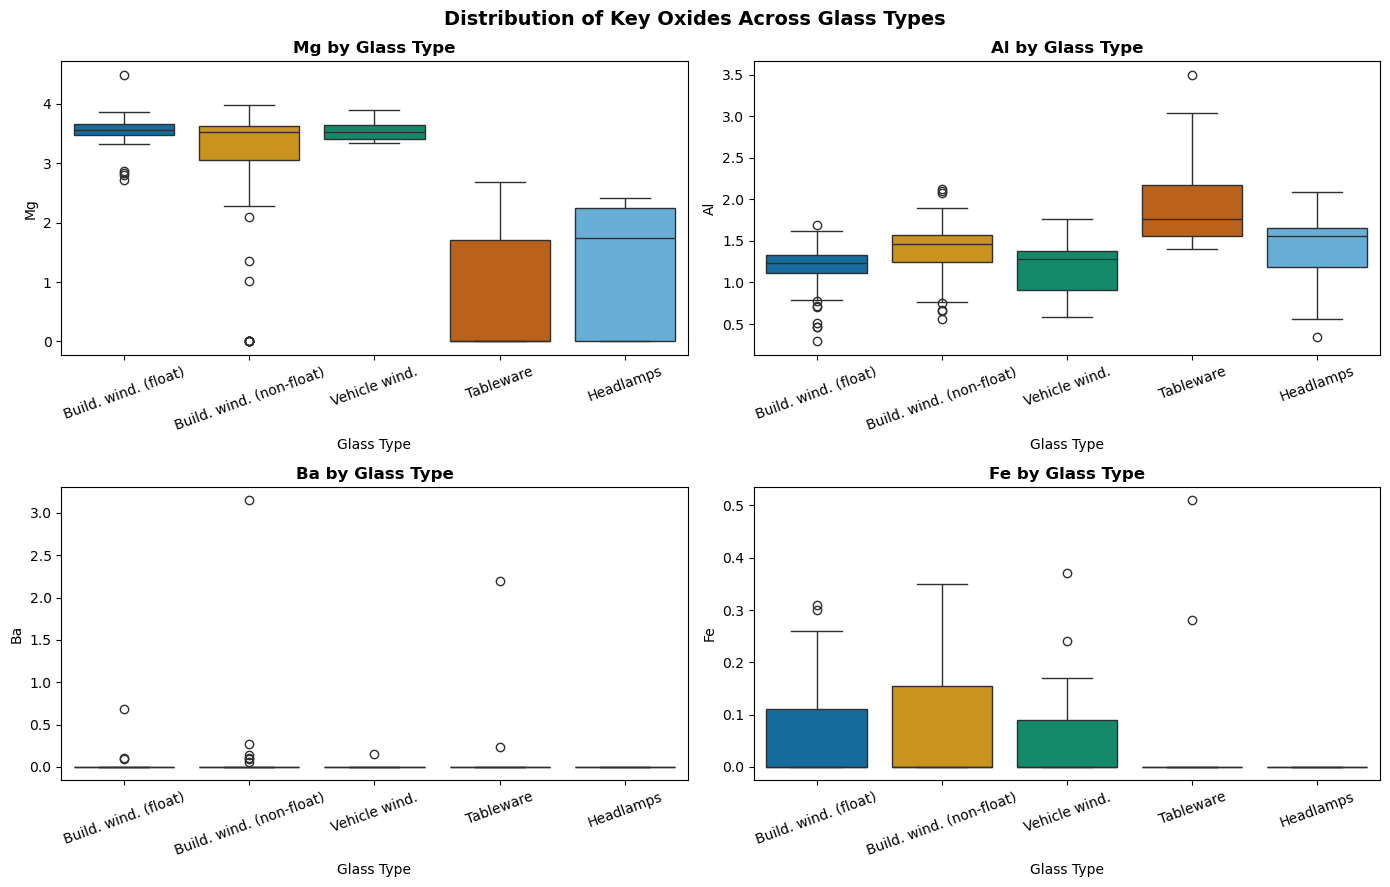

In [127]:
key_oxides = ['Mg', 'Al', 'Ba', 'Fe']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for idx, oxide in enumerate(key_oxides):
    sns.boxplot(data=df_g, x='type_label', y=oxide, hue='type_label', palette=glass_palette, legend=False, ax=axes[idx])
    axes[idx].set_title(f'{oxide} by Glass Type', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Glass Type')
    axes[idx].set_ylabel(oxide)
    axes[idx].tick_params(axis='x', rotation=20)

plt.suptitle('Distribution of Key Oxides Across Glass Types', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## PCA Analysis

We evaluate PCA with both 2 and 3 components to support:
- 2D visualization,
- 3D visualization,
- variance-retention comparison,
- interpretability via biplots.

In [128]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardize first because PCA is scale-sensitive
scaler_g = StandardScaler()
X_g_scaled = scaler_g.fit_transform(X_g)

# Fit PCA models for 2D, 3D and full-spectrum variance analysis
pca_g_2 = PCA(n_components=2)
X_g_pca_2 = pca_g_2.fit_transform(X_g_scaled)

pca_g_3 = PCA(n_components=3)
X_g_pca_3 = pca_g_3.fit_transform(X_g_scaled)

pca_g_full = PCA().fit(X_g_scaled)
cumvar_g = np.cumsum(pca_g_full.explained_variance_ratio_)

print("Explained variance ratio (2 components):")
for i, var in enumerate(pca_g_2.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")
print(f"  Total (2 PCs): {pca_g_2.explained_variance_ratio_.sum()*100:.2f}%")

print("\nExplained variance ratio (3 components):")
for i, var in enumerate(pca_g_3.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")
print(f"  Total (3 PCs): {pca_g_3.explained_variance_ratio_.sum()*100:.2f}%")

print("\nComponent loadings (3-component model):")
loadings_g_3 = pd.DataFrame(
    pca_g_3.components_.T,
    index=X_g.columns,
    columns=['PC1', 'PC2', 'PC3']
)
display(loadings_g_3)

Explained variance ratio (2 components):
  PC1: 0.2790 (27.90%)
  PC2: 0.2278 (22.78%)
  Total (2 PCs): 50.68%

Explained variance ratio (3 components):
  PC1: 0.2790 (27.90%)
  PC2: 0.2278 (22.78%)
  PC3: 0.1561 (15.61%)
  Total (3 PCs): 66.29%

Component loadings (3-component model):


,PC1,PC2,PC3
RI,0.545177,-0.285683,0.086911
Na,-0.258126,-0.270350,-0.384920
Mg,0.110881,0.593558,0.008418
Al,-0.428709,-0.295212,0.329237
Si,-0.228836,0.155099,-0.458709
K,-0.219344,0.153970,0.662574
Ca,0.492306,-0.345380,-0.000985
Ba,-0.250375,-0.484702,0.074055
Fe,0.185842,0.062039,0.284451


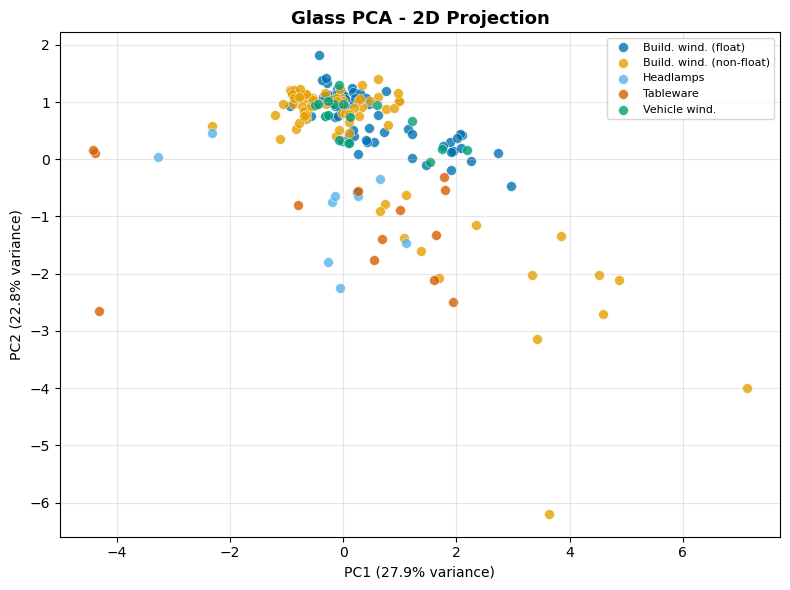

In [129]:
# 2D PCA scatter plot
pca_g_df_2 = pd.DataFrame(X_g_pca_2, columns=['PC1', 'PC2'])
pca_g_df_2['type_label'] = df_g['type_label'].values

plt.figure(figsize=(8, 6))
for label, group in pca_g_df_2.groupby('type_label'):
    plt.scatter(
        group['PC1'], group['PC2'],
        label=label, alpha=0.8, s=50,
        color=glass_palette[label], edgecolors='white', linewidths=0.4
    )

plt.xlabel(f"PC1 ({pca_g_2.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca_g_2.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title('Glass PCA - 2D Projection', fontsize=13, fontweight='bold')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

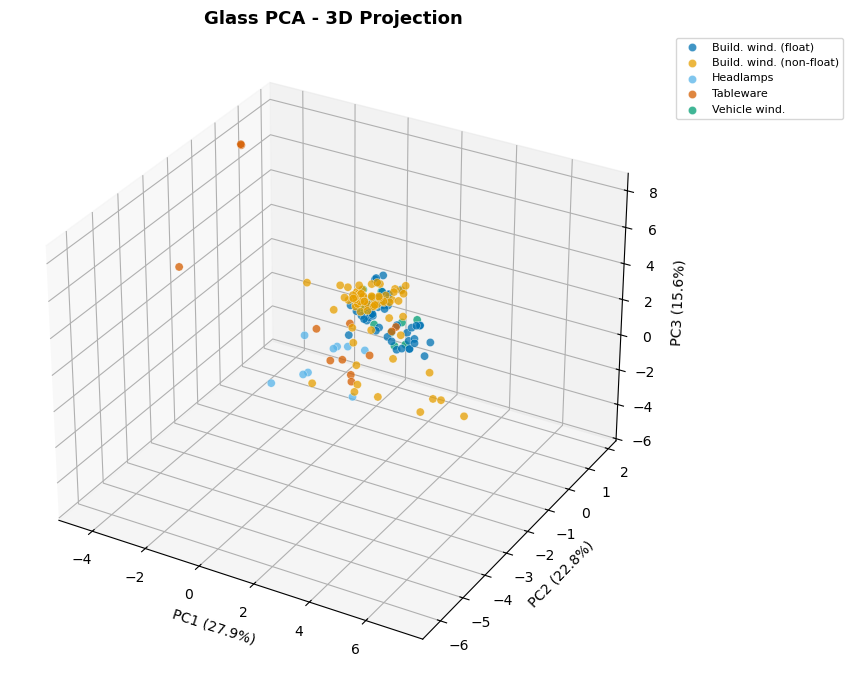

In [130]:
# 3D PCA scatter plot
pca_g_df_3 = pd.DataFrame(X_g_pca_3, columns=['PC1', 'PC2', 'PC3'])
pca_g_df_3['type_label'] = df_g['type_label'].values

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

for label, group in pca_g_df_3.groupby('type_label'):
    ax.scatter(
        group['PC1'], group['PC2'], group['PC3'],
        label=label, alpha=0.75, s=35,
        color=glass_palette[label], edgecolors='white', linewidths=0.3
    )

ax.set_xlabel(f"PC1 ({pca_g_3.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_g_3.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_zlabel(f"PC3 ({pca_g_3.explained_variance_ratio_[2]*100:.1f}%)")
ax.set_title('Glass PCA - 3D Projection', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
plt.show()

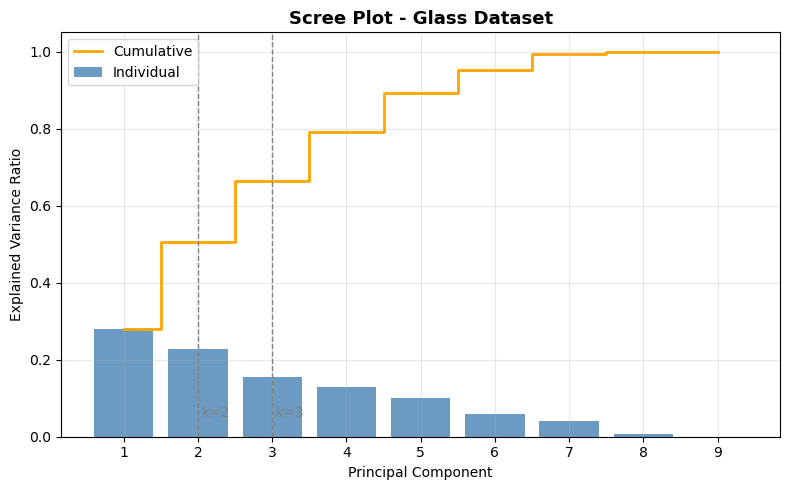

In [131]:
# Scree plot (individual + cumulative explained variance)
plt.figure(figsize=(8, 5))
plt.bar(
    range(1, len(cumvar_g) + 1),
    pca_g_full.explained_variance_ratio_,
    color='steelblue', alpha=0.8, label='Individual'
)
plt.step(
    range(1, len(cumvar_g) + 1),
    cumvar_g, where='mid',
    color='orange', linewidth=2, label='Cumulative'
)
plt.axvline(2, color='grey', linestyle='--', linewidth=1)
plt.axvline(3, color='grey', linestyle='--', linewidth=1)
plt.text(2.05, 0.05, 'k=2', color='grey')
plt.text(3.05, 0.05, 'k=3', color='grey')

plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot - Glass Dataset', fontsize=13, fontweight='bold')
plt.xticks(range(1, len(cumvar_g) + 1))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

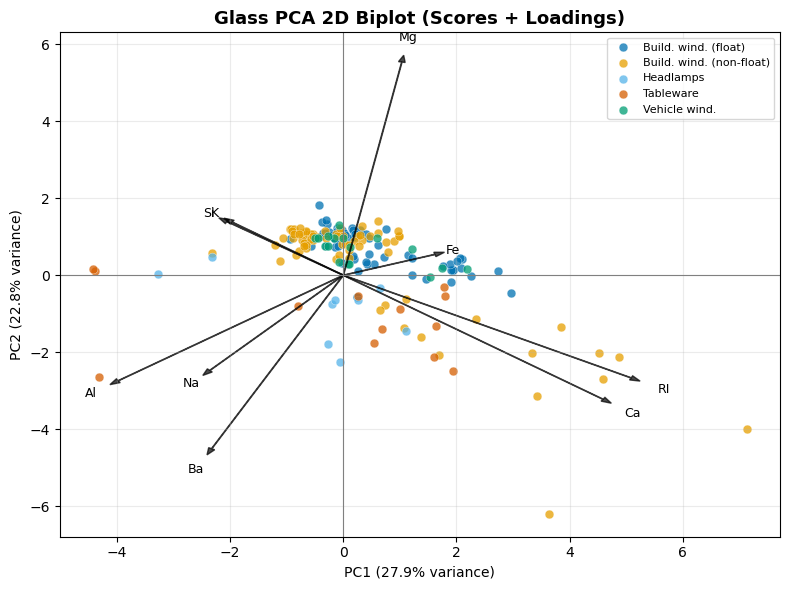

In [132]:
# 2D biplot (scores + loadings)
fig, ax = plt.subplots(figsize=(8, 6))

for label, group in pca_g_df_2.groupby('type_label'):
    ax.scatter(
        group['PC1'], group['PC2'],
        label=label, alpha=0.75, s=40,
        color=glass_palette[label], edgecolors='white', linewidths=0.3
    )

score_max_2d = np.abs(X_g_pca_2[:, :2]).max()
loading_max_2d = np.abs(pca_g_2.components_[:2, :]).max()
arrow_scale_2d = 0.8 * score_max_2d / loading_max_2d

for i, feature in enumerate(X_g.columns):
    x_vec = pca_g_2.components_[0, i] * arrow_scale_2d
    y_vec = pca_g_2.components_[1, i] * arrow_scale_2d
    ax.arrow(0, 0, x_vec, y_vec, color='black', alpha=0.7, width=0.01, head_width=0.12, length_includes_head=True)
    ax.text(x_vec * 1.08, y_vec * 1.08, feature, fontsize=9, ha='center', va='center')

ax.axhline(0, color='grey', linewidth=0.8)
ax.axvline(0, color='grey', linewidth=0.8)
ax.set_xlabel(f"PC1 ({pca_g_2.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca_g_2.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title('Glass PCA 2D Biplot (Scores + Loadings)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

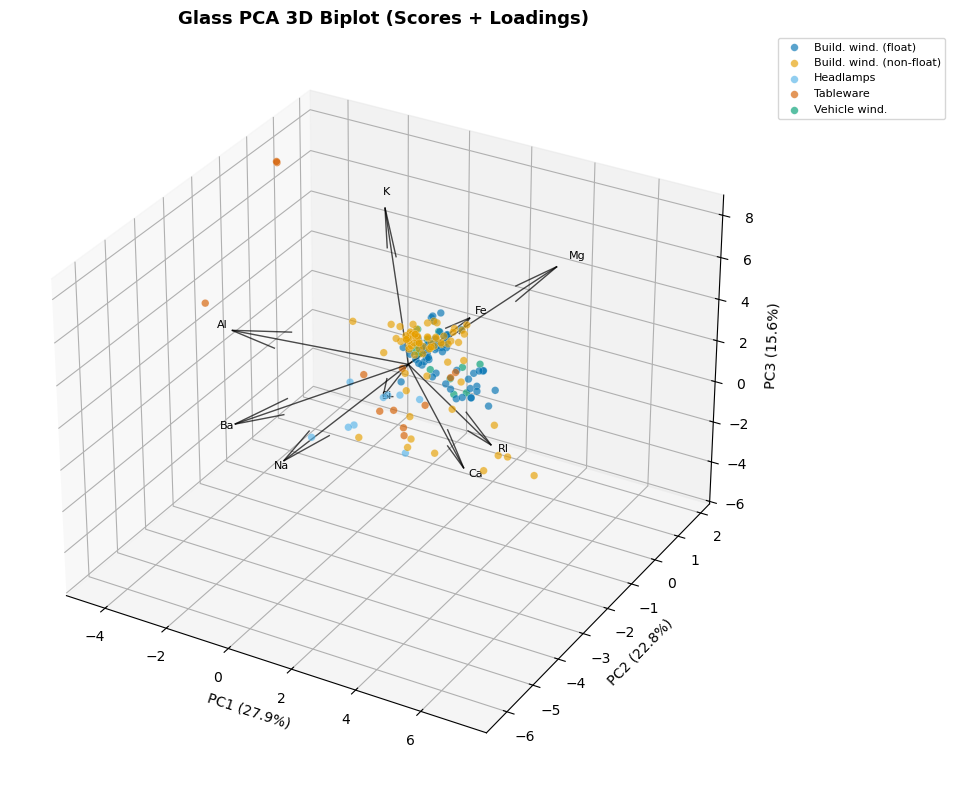

In [133]:
# 3D biplot (scores + loadings)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for label, group in pca_g_df_3.groupby('type_label'):
    ax.scatter(
        group['PC1'], group['PC2'], group['PC3'],
        label=label, alpha=0.65, s=30,
        color=glass_palette[label], edgecolors='white', linewidths=0.2
    )

score_max_3d = np.abs(X_g_pca_3[:, :3]).max()
loading_max_3d = np.abs(pca_g_3.components_[:3, :]).max()
arrow_scale_3d = 0.7 * score_max_3d / loading_max_3d

for i, feature in enumerate(X_g.columns):
    x_vec = pca_g_3.components_[0, i] * arrow_scale_3d
    y_vec = pca_g_3.components_[1, i] * arrow_scale_3d
    z_vec = pca_g_3.components_[2, i] * arrow_scale_3d
    ax.quiver(0, 0, 0, x_vec, y_vec, z_vec, color='black', alpha=0.7, linewidth=1.0)
    ax.text(x_vec * 1.08, y_vec * 1.08, z_vec * 1.08, feature, fontsize=8)

ax.set_xlabel(f"PC1 ({pca_g_3.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_g_3.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_zlabel(f"PC3 ({pca_g_3.explained_variance_ratio_[2]*100:.1f}%)")
ax.set_title('Glass PCA 3D Biplot (Scores + Loadings)', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
plt.show()